# 3.2  Análisis de vocabulario para comparar períodos de 5 años

* Explorar frecuencias de palabras: Filtrado por frecuencia mínima. 

* Vocabulario: Medir qué proporción del vocabulario permanece activo (por encima del umbral de frecuencia) en los tres períodos.

* Identificar palabras emergentes: detectar palabras que aparecen o aumentan significativamente su uso en un período respecto a otro.




#### Iniciativa legislativa de ley sobre SALUD - muerte subita para período parlamentario entre 127 a 141
* 9 iniciativas legislativas

Analizando proyectos de IL de Salud:
* [2009 - 2014) 
    * Número total de tokens: 1715 // 7854
    * Número de tokens únicos: 801 //1713
* [2014 - 2019)
    * Número total de tokens: 1850 // 9740
    * Número de tokens únicos: 686 // 1969
* [2019 - 2024)
    * Número total de tokens: 1893 // 10222
    * Número de tokens únicos: 694 // 1876


## 1. EDA

In [1]:
# Importar librerias

from dotenv import load_dotenv
import os
import pandas as pd
import numpy as np
import pickle
import sweetviz as sv
import sys

# Visualización
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from matplotlib import colormaps

from collections import Counter
from itertools import islice

from tqdm import tqdm
tqdm.pandas()

In [2]:
import datetime
print(datetime.datetime.now().strftime("%Y%m%d%H%M"))

202505102213


In [3]:
# Configurar path
load_dotenv() # Cargar las variables de entorno del archivo .env
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") + 'muerte_subita/'# Acceder a las variables de entorno
sys.path.append(BASE_DIR)
sys.path.append(RESULTADOS_DIR)

pd.set_option('display.max_colwidth', None)

In [4]:
# Abrir
with open(RESULTADOS_DIR + 'base_texto_df_ley_0924.pkl', 'rb') as file: 
    basetexto_df = pickle.load(file)

basetexto_df.describe(include='all').T

count unique  \
Proyecto.ID                            8      8   
texto_proyecto                         8      8   
texto_proyecto procesado               8      7   
texto_proyecto normalizado             8      7   
Cant_token                           8.0    NaN   
Cant_token_normalizado               8.0    NaN   
Proyecto_girado_a_comisiones_SALUD   8.0    NaN   
Proyecto_SALUD                       8.0    NaN   
Resultado                              8      1   
Max_Orden                            8.0    NaN   
Tiene_antecedente_por_titulo_proy      8      2   
Periodo                              8.0    NaN   
Año                                  8.0    NaN   
Tokens                                 8      7   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [5]:
# Seleccionando IL de Salud
basetexto_df = basetexto_df[basetexto_df['Proyecto_SALUD']==1]
print("Conj. de datos de proyecto_SALUD con Nan en Período:",basetexto_df.shape)
basetexto_df = basetexto_df[~basetexto_df['Periodo'].isna()]
print("Conj. de datos de proyecto_SALUD sin Nan en Período:",basetexto_df.shape)

Conj. de datos de proyecto_SALUD con Nan en Período: (8, 14)
Conj. de datos de proyecto_SALUD sin Nan en Período: (8, 14)


In [6]:
basetexto_df = basetexto_df[~(basetexto_df['texto_proyecto normalizado']==" ")]
print("Conj. de datos de proyecto_SALUD sin texto_proyecto vacio:",basetexto_df.shape)

Conj. de datos de proyecto_SALUD sin texto_proyecto vacio: (8, 14)


In [7]:
basetexto_df[['Cant_token','Cant_token_normalizado']].describe()

,Cant_token,Cant_token_normalizado
count,8.000000,8.000000
mean,1496.500000,682.250000
std,338.549005,158.648533
min,1184.000000,532.000000
25%,1202.000000,541.750000
50%,1433.500000,667.500000
75%,1720.250000,787.000000
max,2078.000000,938.000000


Calculamos el promedio de tokens anuales y luego el promedio de esos promedios para obtener un resumen de 16 años  (media de las medias).

In [8]:
Temp = pd.pivot_table(basetexto_df, values=['Cant_token','Cant_token_normalizado'], 
                      index=['Año'],
                       aggfunc={'Cant_token': 'median','Cant_token_normalizado': 'median'}).reset_index()
Temp

,Año,Cant_token,Cant_token_normalizado
0,2009,1715.0,777.0
1,2012,2078.0,938.0
2,2014,1736.0,786.0
3,2016,1184.0,532.0
4,2018,1184.0,532.0
5,2020,1416.0,667.5
6,2022,1243.0,558.0


 Para expresar el error asociado a este valor resumen, observamos las estadística descriptiva y calculamos el Error Estándar de la Media (SEM, Standard Error of the Mean) de los promedios anuales.

In [9]:
Temp.describe().T

,count,mean,std,min,25%,50%,75%,max
Año,7.0,2015.857143,4.561746,2009.0,2013.0,2016.0,2019.0,2022.0
Cant_token,7.0,1508.000000,343.601998,1184.0,1213.5,1416.0,1725.5,2078.0
Cant_token_normalizado,7.0,684.357143,155.951038,532.0,545.0,667.5,781.5,938.0


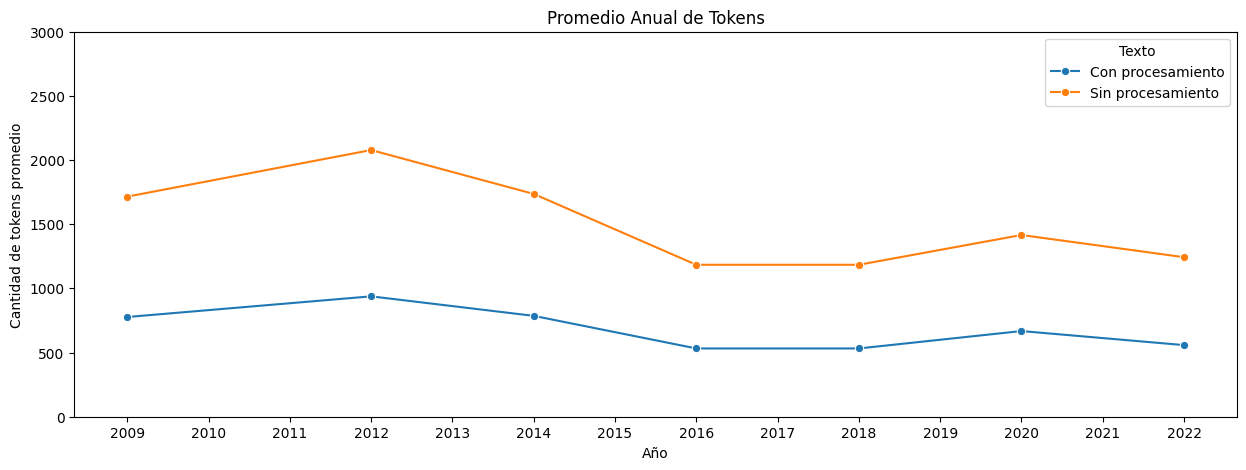

In [10]:
import matplotlib.ticker as ticker
sns.color_palette("pastel")
Temp1 = pd.melt(Temp, id_vars=['Año'], value_vars=['Cant_token_normalizado', 'Cant_token'])
Temp1.columns = ['Año','Texto','Cantidad de tokens promedio']
Temp1["Texto"] = Temp1["Texto"].map({'Cant_token': 'Sin procesamiento', 'Cant_token_normalizado': 'Con procesamiento'})

f, ax = plt.subplots(1, 1, figsize=(15, 5), sharey = True)
sns.lineplot(x='Año', y='Cantidad de tokens promedio', hue='Texto', data = Temp1, estimator='sum', errorbar= None , linestyle='-', ax = ax, marker="o")
legend_handles, _= ax.get_legend_handles_labels()

ax.set_title('Promedio Anual de Tokens')
plt.ylim(0, 3000)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=15))
plt.savefig(BASE_DIR+"imagenes/evolucion_IL_a_tokennos_muerte_subita.png")
plt.show()

Textos más largos antes?

In [11]:
from scipy import stats

# Calcula la media de los promedios anuales
promedios_anuales = Temp['Cant_token_normalizado']
n = len(promedios_anuales)
media_total = np.mean(promedios_anuales)

# Calcula la desviación estándar de los promedios anuales
desviacion_estandar = np.std(promedios_anuales, ddof=1) # ddof=1 para desviación estándar de la muestra

# Calcula el Error Estándar de la Media (SEM)
sem = desviacion_estandar / np.sqrt(n)
print('desviacion_estandar', desviacion_estandar)
print('sem',sem)

# Calcula el Intervalo de Confianza del 95%
alpha = 0.05  # Nivel de significancia
grados_libertad = n - 1
valor_critico_t = stats.t.ppf(1 - alpha / 2, grados_libertad)
intervalo_confianza = valor_critico_t * sem



desviacion_estandar 155.95103779865076
sem 58.943951816809104


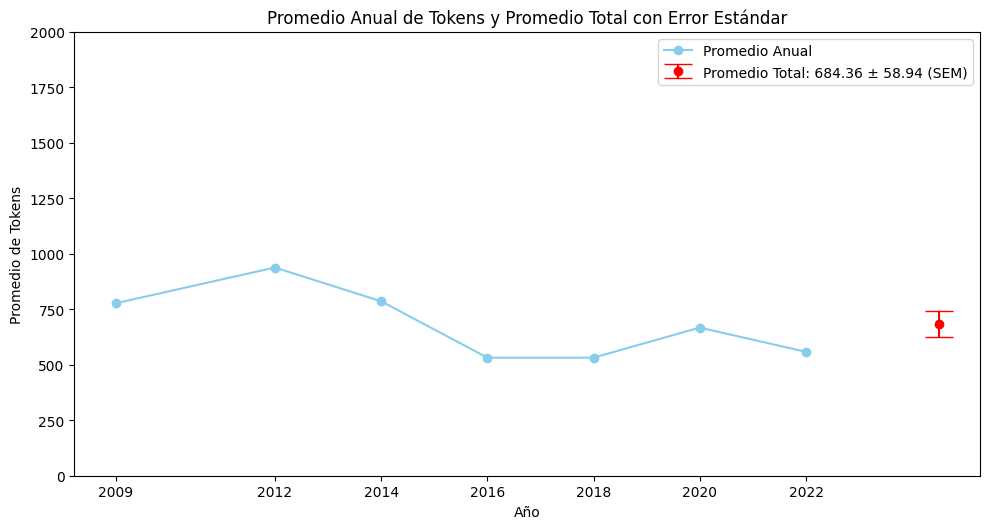

In [12]:
# --- Gráfico de Líneas con Punto Resumen y Error (SEM) ---
anos = Temp['Año']
plt.figure(figsize=(10,6))
plt.plot(anos, promedios_anuales, marker='o', linestyle='-', color='skyblue', label='Promedio Anual')
plt.errorbar(2024.5, media_total, yerr=sem, fmt='o', color='red', capsize=10, label=f'Promedio Total: {media_total:.2f} ± {sem:.2f} (SEM)')
plt.xlabel("Año")
plt.ylabel("Promedio de Tokens")
plt.title("Promedio Anual de Tokens y Promedio Total con Error Estándar")
plt.ylim(0, 2000)
plt.xticks(anos.tolist() )
plt.legend()
plt.grid(False)
#plt.tight_layout()
plt.tight_layout(rect=[0, 0.05, 1, 0.95]) # Ajuste para evitar cortar etiquetas

plt.show()

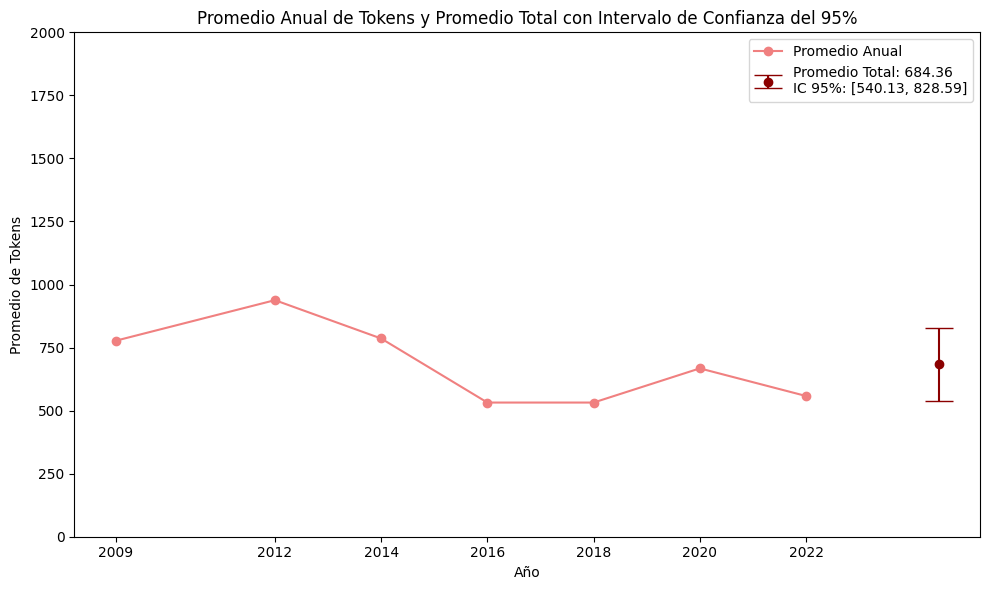

In [13]:
# --- Gráfico de Líneas con Punto Resumen y Error (Intervalo de Confianza del 95%) ---
plt.figure(figsize=(10, 6))
plt.plot(anos, promedios_anuales, marker='o', linestyle='-', color='lightcoral', label='Promedio Anual')
plt.errorbar(2024.5, media_total, yerr=intervalo_confianza, fmt='o', color='darkred', capsize=10,
             label=f'Promedio Total: {media_total:.2f}\nIC 95%: [{media_total - intervalo_confianza:.2f}, {media_total + intervalo_confianza:.2f}]')
plt.xlabel("Año")
plt.ylabel("Promedio de Tokens")
plt.title("Promedio Anual de Tokens y Promedio Total con Intervalo de Confianza del 95%")
plt.ylim(0, 2000)
plt.xticks(anos.tolist())
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

**Normalizado**
* Media de los promedios anuales: 684
* Desviación estándar de los promedios anuales: 156
* SEM: 59

El SEM da una idea de la precisión con la que la media de los promedios anuales estima la "verdadera" media del promedio anual de tokens para el periodo de 16 años. El SEM es alto indica que la media de los promedios anuales no es probablemente una estimación precisa de la "verdadera" media.

La media de 684 es una estimación del promedio anual de tokens para el periodo de 16 años. 
La mayoría de los promedios anuales de tokens se encuentran relativamente lejos de la media. 

## 2. Corpus para los tres períodos

La selección de períodos de cada 5 años se basa a los periodos de presidencia. Es importante tener en cuenta a la hora de comparar el año 2020, dado que fue el año de inicio de pandemía covid 19, en donde se priorizaron proyectos de salud más que en los otros años. Ver notebook de EDA

* Periodo: 10 de diciembre de 2023 al presente
  Presidente Javier Milei
Ministro de Defensa
Dr. Luis Alfonso Petri

* Periodo: 10 de agosto de 2021 al 10 de diciembre de 2023
Presidente Alberto Fernández
Ministro de Defensa
Lic. Jorge Enrique Taiana

* Periodo: 10 de diciembre de 2019 al 10 de Agosto 2021
Presidente Alberto Fernández
Ministro de Defensa
Ing. Agustín Oscar Rossi

* Periodo: 10 de diciembre de 2015 al 10 de diciembre de 2019
Presidente Mauricio Macri
Ministro de Defensa
Ing. Julio César Martínez – 2015-2017
Dr. Oscar Raúl Aguad – 2017 al 2019

* Periodo: 10 de diciembre de 2011 al 10 de diciembre de 2015
Presidenta Cristina Fernández de Kirchner. Re-elección
Ministro de Defensa
Ing. Agustín Oscar Rossi – 2013 - 2015
Arturo Puricelli – 2011 - 2013

* Periodo: 10 de diciembre de 2007 al 10 de diciembre de 2011
Presidenta Cristina Fernández de Kirchner
Ministro de Defensa
Arturo Puricelli – 2010 - 2011
Nilda Garré – 2007 - 2010

In [14]:
basetexto_df['Periodo_5anios'] = 2009
basetexto_df.loc[(basetexto_df['Año']>=2014) & (basetexto_df['Año']<2019), 'Periodo_5anios'] =  2014
basetexto_df.loc[(basetexto_df['Año']>=2019), 'Periodo_5anios'] =  2019

In [15]:
basetexto_df['Periodo_5anios'].value_counts() # frecuencia absoluto

Periodo_5anios
2019    3
2014    3
2009    2
Name: count, dtype: int64

In [16]:
Temp = pd.pivot_table(basetexto_df, values=['Cant_token','Cant_token_normalizado'], 
                      index=['Periodo_5anios'],
                       aggfunc={'Cant_token': 'median','Cant_token_normalizado': 'median'}).reset_index()
Temp.columns = ['Periodo_5anios',	'promedio Cant_token',	'promedio Cant_token_normalizado']
Temp

,Periodo_5anios,promedio Cant_token,promedio Cant_token_normalizado
0,2009,1896.5,857.5
1,2014,1184.0,532.0
2,2019,1243.0,558.0


In [17]:
#concatenando titulos IL
PER5anios_df = basetexto_df.groupby('Periodo_5anios')['texto_proyecto normalizado'].progress_apply('.'.join).reset_index() 
PER5anios_df['corpus']= PER5anios_df['texto_proyecto normalizado'].progress_apply(lambda x: [sent.split() for sent in x.split('.')])
PER5anios_df['corpus'] = PER5anios_df['corpus'].progress_apply(lambda x: [token.remove(' ') if ' ' in token else token  for token in x ])


100%|██████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 3007.39it/s]


In [18]:
print(len(PER5anios_df['corpus'].values[0]))
PER5anios_df['corpus'].values[0]

2


[['proyecto',
  'senado',
  'camara',
  'diputado',
  'ley',
  'prevencion',
  'espacio',
  'acceso',
  'publico',
  'capitulo',
  'disposicion',
  'general',
  'articulo',
  'objeto',
  'objeto',
  'presente',
  'ley',
  'regular',
  'sistema',
  'prevencion',
  'integral',
  'evento',
  'espacio',
  'publico',
  'privado',
  'acceso',
  'publico',
  'articulo',
  'definicion',
  'efecto',
  'ley',
  'considerar',
  'resucitacion',
  'cardiopulmonar',
  'rcp',
  'maniobra',
  'cabo',
  'persona',
  'caso',
  'detencion',
  'circulacion',
  'sangre',
  'destinado',
  'oxigenacion',
  'inmediato',
  'organo',
  'vital',
  'desfibrilacion',
  'maniobra',
  'rcp',
  'incluir',
  'desfibrilador',
  'externo',
  'automatico',
  'dea',
  'desfibrilador',
  'externo',
  'automatico',
  'dea',
  'dispositivo',
  'portatil',
  'utilizado',
  'estimular',
  'electricamente',
  'corazon',
  'persona',
  'paro',
  'cardiaco',
  'espacio',
  'publico',
  'privado',
  'acceso',
  'publico',
  'lugar

In [19]:
# GUARDAR OBJETO PARA DETECTAR CAMBIOS SEMANTICOS
#with open(RESULTADOS_DIR + 'periodo_5anios_df.pkl', 'wb') as file: 
#    pickle.dump(PER5anios_df,file)

## 3. Analizando frecuencias de palabras por período 
Se tiene en cuenta los períodos parlamentaríos


In [20]:
freqs_list = []
for anios5 in PER5anios_df['Periodo_5anios'].to_list():

    print(anios5)
    subdf = PER5anios_df.loc[(PER5anios_df['Periodo_5anios']==anios5),]
    subdf['texto_proyecto normalizado'] = subdf['texto_proyecto normalizado'].str.replace("."," ")                                 
    
    freqs = Counter()
    subdf['texto_proyecto normalizado'].apply(lambda x: freqs.update(x.split())) # cualquier espacio.
    total_number = sum(freqs.values())
    print('Número total de tokens:', total_number)

    freqs_df = pd.DataFrame.from_dict(freqs, orient='index',
                                      columns=['Frecuencia'])
    freqs_df = freqs_df.reset_index()

    freqs_df = freqs_df.rename(columns={'index': 'Palabra'})
    mask = (freqs_df['Palabra'].str.len() > 1)
    print(freqs_df.shape)
    freqs_df = freqs_df.loc[mask]
    print(freqs_df.shape)
    print('Entradas removidas de 1 carácter.')
    print('Cantidad de tokens únicos:', freqs_df.shape[0])

    freqs_df = freqs_df.sort_values('Frecuencia').reset_index(drop=True)

    freqs_df['Porcentaje'] = freqs_df['Frecuencia'] / total_number

    
    freqs_df.to_csv(RESULTADOS_DIR+'./archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(anios5)+'.csv', index=False)

    freqs_df['Período'] = str(anios5)
    
    freqs_list.append(freqs_df)
    

2009
Número total de tokens: 1715
(801, 2)
(801, 2)
Entradas removidas de 1 carácter.
Cantidad de tokens únicos: 801
2014
Número total de tokens: 1850
(686, 2)
(686, 2)
Entradas removidas de 1 carácter.
Cantidad de tokens únicos: 686
2019
Número total de tokens: 1893
(694, 2)
(694, 2)
Entradas removidas de 1 carácter.
Cantidad de tokens únicos: 694


C:\Users\Usuario\AppData\Local\Temp\ipykernel_22352\980080312.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf['texto_proyecto normalizado'] = subdf['texto_proyecto normalizado'].str.replace("."," ")
C:\Users\Usuario\AppData\Local\Temp\ipykernel_22352\980080312.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf['texto_proyecto normalizado'] = subdf['texto_proyecto normalizado'].str.replace("."," ")
C:\Users\Usuario\AppData\Local\Temp\ipykernel_22352\980080312.py:6: SettingWithCopyWarning: 
A

In [21]:
freqs_df = pd.concat(freqs_list) # Dataframe de frecuecias

In [22]:
freqs_df.head(2)

,Palabra,Frecuencia,Porcentaje,Período
0,eventual,1,0.000583,2009
1,crear,1,0.000583,2009


##### VOCABULARIO por período de 5 años

Analizando proyectos de IL de Salud:
* [2009 - 2014) 
    * Número total de tokens: 1715 // 7854
    * Número de tokens únicos: 801 //1713
* [2014 - 2019)
    * Número total de tokens: 1850 // 9740
    * Número de tokens únicos: 686 // 1969
* [2019 - 2024)
    * Número total de tokens: 1893 // 10222
    * Número de tokens únicos: 694 // 1876

### Análisis general (Tres Periodos Combinados)

In [23]:
vocab_periodo = freqs_df['Período'].value_counts().reset_index() # vocabulario por períodos de 5 años
vocab_periodo

,Período,count
0,2009,801
1,2019,694
2,2014,686


In [25]:
vocab_periodo.describe() # Estadística

,count
count,3.000000
mean,727.000000
std,64.210591
min,686.000000
25%,690.000000
50%,694.000000
75%,747.500000
max,801.000000


In [26]:
# Calculo la media de cantidad de palabras del vocabulario
 
n = len(vocab_periodo['count'])
media_total = np.mean(vocab_periodo['count'])

# Calcula la desviación estándar de los promedios anuales
desviacion_estandar = np.std(vocab_periodo['count'], ddof=1) # ddof=1 para desviación estándar de la muestra

# Calcula el Error Estándar de la Media (SEM)
sem = desviacion_estandar / np.sqrt(n)
print('media de vocabulario por periodo (cantidad de palabras únicas)',media_total)
print('desviacion_estandar', desviacion_estandar)
coeficiente_variacion = (desviacion_estandar / media_total) * 100
print('coeficiente_variacion ',coeficiente_variacion)
print('sem',sem)

# Calcula el Intervalo de Confianza del 95%
alpha = 0.05  # Nivel de significancia
grados_libertad = n - 1
valor_critico_t = stats.t.ppf(1 - alpha / 2, grados_libertad)
intervalo_confianza = valor_critico_t * sem
print("intervalo de confianza: ",intervalo_confianza)

media de vocabulario por periodo (cantidad de palabras únicas) 727.0
desviacion_estandar 64.21059102671458
coeficiente_variacion  8.83226836681081
sem 37.072002014098636
intervalo de confianza:  159.50795066126236


La desviación estándar es de 64 palabras, el Coeficiente de Variación de 9 (dispersión relativa), lo que indica que los vocabularios o las cantidades de palabras únicas por período están más dispersas, la media 727 no es tan representativa para los tres periodos a procesar.

In [27]:
freqs_df = freqs_df.sort_values(by = 'Frecuencia', ascending =False)

In [28]:

freqs_df.to_csv(RESULTADOS_DIR+'/archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_all.csv', index=False)


In [29]:
# Suponiendo que tu DataFrame se llama 'df'
print("--- Análisis del Vocabulario para los Tres Periodos Combinados ---")

# 1. Tamaño total del vocabulario único
vocabulario_total = freqs_df['Palabra'].nunique()
print(f"Tamaño total del vocabulario único en los tres periodos: {vocabulario_total}")

# 2. Frecuencia total de todas las palabras
frecuencia_total = freqs_df['Frecuencia'].sum()
print(f"Frecuencia total de todas las palabras en los tres periodos: {frecuencia_total}")


--- Análisis del Vocabulario para los Tres Periodos Combinados ---
Tamaño total del vocabulario único en los tres periodos: 1220
Frecuencia total de todas las palabras en los tres periodos: 5458


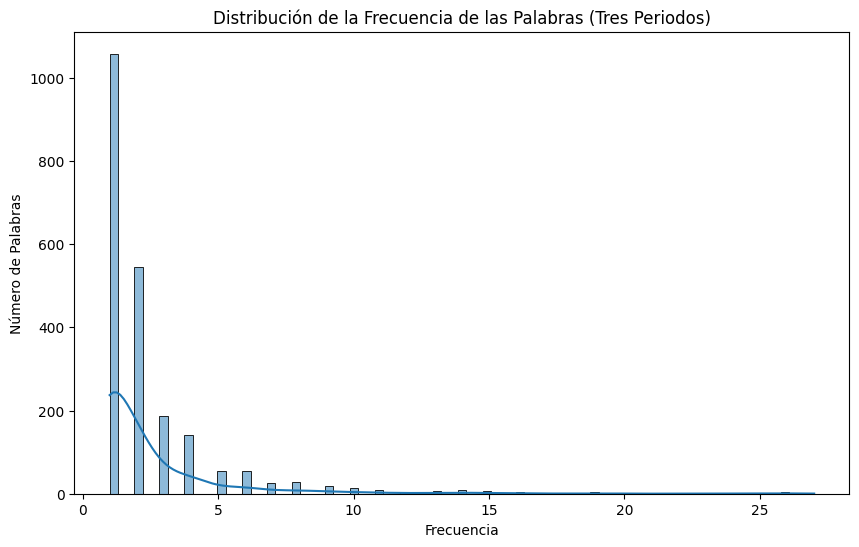

In [30]:
# 3. Distribución de la frecuencia de las palabras
plt.figure(figsize=(10, 6))
sns.histplot(freqs_df['Frecuencia'], bins='auto', kde=True)
plt.title('Distribución de la Frecuencia de las Palabras (Tres Periodos)')
plt.xlabel('Frecuencia')
plt.ylabel('Número de Palabras')
plt.show()

<Axes: xlabel='Frecuencia'>

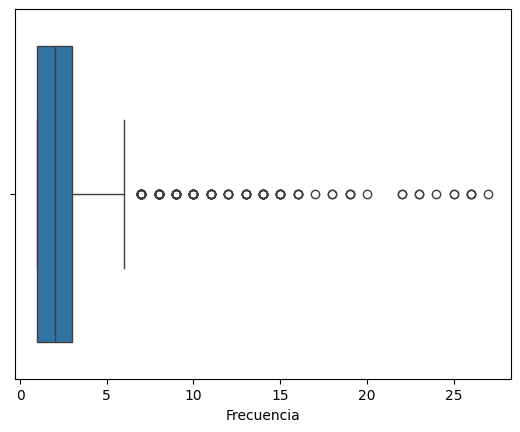

In [31]:
sns.boxplot(x = 'Frecuencia', data=freqs_df)

In [32]:
freqs_df.describe(include = 'all') 

,Palabra,Frecuencia,Porcentaje,Período
count,2181,2181.000000,2181.000000,2181
unique,1220,NaN,NaN,3
top,articulo,NaN,NaN,2009
freq,3,NaN,NaN,801
mean,NaN,2.502522,0.001376,NaN
std,NaN,2.895998,0.001592,NaN
min,NaN,1.000000,0.000528,NaN
25%,NaN,1.000000,0.000541,NaN
50%,NaN,2.000000,0.001057,NaN
75%,NaN,3.000000,0.001585,NaN


In [33]:
rango = np.max(freqs_df['Frecuencia']) - np.min(freqs_df['Frecuencia'])
coeficiente_variacion = (desviacion_estandar / freqs_df['Frecuencia'].mean()) * 100
print('Rango ',rango)
print('Coeficiente_variacion ',coeficiente_variacion)


Rango  26
Coeficiente_variacion  2565.8354530828965


* El frecuencia promedia de una palabra en período de 5 años es: 3
* La frecuencia media de una palabra en período de 5 años es: 2
* La desviación estandar de una palabra en período de 5 años es: 3
* El rango de frecuencia de una palabra en período de 5 años es: 26

Existe variabilidad de frecuencia de palabra en período de 5 años (rango = 26 frecuencia). La mayorías de las palabras en período de 5 años tienen baja frecuencia de ocurrencia tal que se concentran alrededor de frecuencia=2. El 75% del total de palabras en los tres periodos presentan una frecuencia inferior a frecuencia = 3. 

In [34]:
def eliminar_outliers_iqr(df, columna):
    """
    Separa los outliers y devuelve dos DataFrames:
    - df_limpio: sin outliers
    - df_outliers: con los valores atípicos detectados

    Parámetros:
    df (pd.DataFrame): DataFrame de pandas
    columna (str): Nombre de la columna a analizar

    Retorna:
    df_limpio (pd.DataFrame): DataFrame sin outliers
    df_outliers (pd.DataFrame): DataFrame solo con outliers
    """
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    # Definir los límites
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    print("Q1:",Q1)
    print("Q3:",Q3)
    print('limite_inferior:', limite_inferior)
    print('limite_superior:', limite_superior)


    # Filtrar datos
    df_limpio = df[(df[columna] >= limite_inferior) & (df[columna] <= limite_superior)]
    df_outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]

    return df_limpio, df_outliers    


In [35]:
# Detectar outliers
freqs_limpio_df , outliers_df = eliminar_outliers_iqr(freqs_df, 'Frecuencia')
display("Outliers detectados:\n", outliers_df)

Q1: 1.0
Q3: 3.0
limite_inferior: -2.0
limite_superior: 6.0


'Outliers detectados:\n'

,Palabra,Frecuencia,Porcentaje,Período
685,articulo,27,0.014595,2014
800,articulo,26,0.015160,2009
798,persona,26,0.015160,2009
799,dea,26,0.015160,2009
693,deportivo,25,0.013207,2019
...,...,...,...,...
631,incluir,7,0.003784,2014
630,problema,7,0.003784,2014
646,presente,7,0.003698,2019
647,forma,7,0.003698,2019


Se considera que una palabra en periodo de 5 años con frecuencia superior 6 es una palabra de frecuencia extrema o especial.

In [37]:
print("Cantidad de palabras únicas por período que superan las 6 veces en alguno de los tres períodos  - OUTLIERS:", len(outliers_df.Palabra.unique()))

Cantidad de palabras únicas por período que superan las 6 veces en alguno de los tres períodos  - OUTLIERS: 78


* Existe variabilidad de frecuencia de palabra en período de 5 años (rango = 26 frecuencia).
* La mayoría de las palabras en período de 5 años tienen baja frecuencia de ocurrencia tal que se  concentran alrededor de frecuencia=2. 
* El 75% del total de palabras en los tres periodos presentan una frecuencia inferior a frecuencia = 3.
* Se considera que una palabra en período de 5 años con frecuencia superior 6 es una palabra de frecuencia extrema o especial. 
* Hay 139 palabras únicas por período que superan las 6 veces en alguno de los tres períodos. 
* Total de palabras con frecuencia extrema en alguno de los tres periodo = 78 


### Análisis por Periodo:  Por período de 5 años

In [38]:
from scipy.stats import bootstrap


# Para una primera aproximación y visualización de la incertidumbre, el bootstrap de percentiles (o la salida por defecto de scipy.stats.bootstrap) es un buen comienzo.
def confidence_intervals(data):
    res = bootstrap((data,), np.mean, confidence_level=0.95, random_state=42) # Añadimos random_state para reproducibilidad
    return (res.confidence_interval.low, res.confidence_interval.high)

def confidence_intervals_bca(data):
    """
    Calcula el intervalo de confianza del 95% para la media utilizando el método BCa bootstrap.
    """
    res = bootstrap((data,), np.mean, confidence_level=0.95, method='BCa', random_state=42)
    return (res.confidence_interval.low, res.confidence_interval.high)




Bootstrap de Percentiles (Percentile Bootstrap):

Cómo funciona: El intervalo de confianza se construye tomando los percentiles apropiados (por ejemplo, el 2.5% y el 97.5% para un intervalo del 95%) de la distribución de las estadísticas bootstrap.
Ventajas: Conceptualmente simple y fácil de entender.
Desventajas: Su precisión puede ser limitada, especialmente con muestras pequeñas o distribuciones sesgadas. No siempre es transformacionalmente invariante (el intervalo de confianza para una función del parámetro no siempre es la función de los límites del intervalo de confianza).


--- Análisis por Periodo ---

--- Periodo: 2009 ---
Tamaño del vocabulario único: 801
Frecuencia total de palabras: 1715
Frecuencia media de las palabras (BCa): 2.14 (IC 95%: 1.97, 2.36)
['articulo' 'dea' 'persona' 'lugar' 'publico' 'cardiaco' 'ley' 'deber'
 'proyecto' 'desfibrilador']


'Top 10 palabras'

,Palabra,Frecuencia,Porcentaje,Período
800,articulo,26,0.015160,2009
799,dea,26,0.015160,2009
798,persona,26,0.015160,2009
797,lugar,23,0.013411,2009
796,publico,22,0.012828,2009
795,cardiaco,20,0.011662,2009
794,ley,17,0.009913,2009
792,deber,15,0.008746,2009
793,proyecto,15,0.008746,2009
791,desfibrilador,14,0.008163,2009


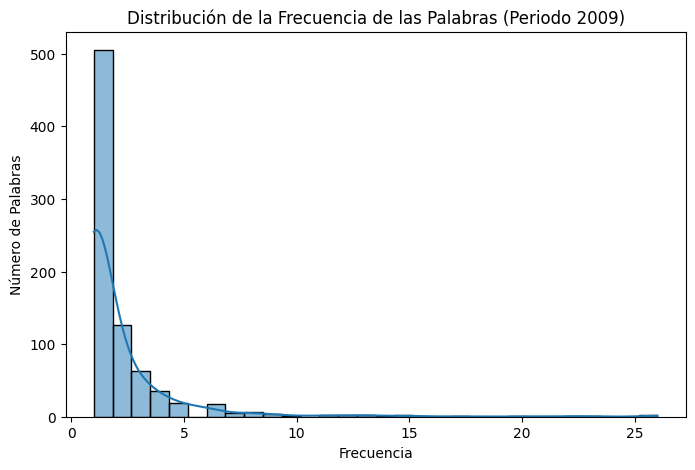


--- Periodo: 2014 ---
Tamaño del vocabulario único: 686
Frecuencia total de palabras: 1850
Frecuencia media de las palabras (BCa): 2.70 (IC 95%: 2.50, 2.94)
['articulo' 'programa' 'deportivo' 'cardiaco' 'actividad' 'nino' 'causa'
 'fisico' 'joven' 'persona']


'Top 10 palabras'

,Palabra,Frecuencia,Porcentaje,Período
685,articulo,27,0.014595,2014
684,programa,22,0.011892,2014
683,deportivo,19,0.010270,2014
682,cardiaco,19,0.010270,2014
681,actividad,18,0.009730,2014
680,nino,18,0.009730,2014
679,causa,16,0.008649,2014
678,fisico,15,0.008108,2014
677,joven,15,0.008108,2014
674,persona,14,0.007568,2014


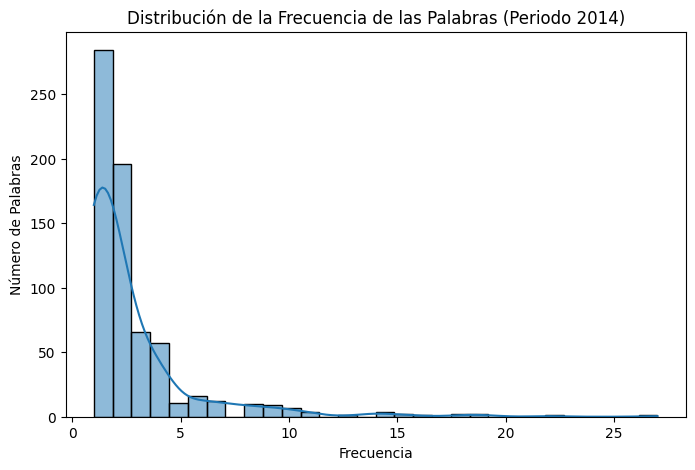


--- Periodo: 2019 ---
Tamaño del vocabulario único: 694
Frecuencia total de palabras: 1893
Frecuencia media de las palabras (BCa): 2.73 (IC 95%: 2.53, 2.98)
['deportivo' 'actividad' 'articulo' 'nino' 'fisico' 'programa' 'deber'
 'establecimiento' 'ley' 'prevencion']


'Top 10 palabras'

,Palabra,Frecuencia,Porcentaje,Período
693,deportivo,25,0.013207,2019
692,actividad,25,0.013207,2019
691,articulo,24,0.012678,2019
690,nino,23,0.012150,2019
689,fisico,19,0.010037,2019
688,programa,16,0.008452,2019
687,deber,16,0.008452,2019
686,establecimiento,16,0.008452,2019
685,ley,15,0.007924,2019
684,prevencion,15,0.007924,2019


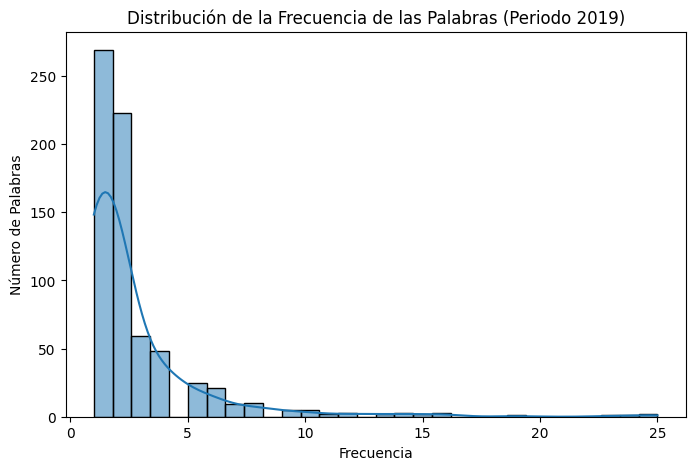

In [39]:
print("\n--- Análisis por Periodo ---")
for periodo in ['2009','2014','2019']:

    df_periodo = freqs_df[freqs_df['Período'] == periodo]
    print(f"\n--- Periodo: {periodo} ---")

    # 1. Tamaño del vocabulario único por periodo
    vocabulario_periodo = df_periodo['Palabra'].nunique()
    print(f"Tamaño del vocabulario único: {vocabulario_periodo}")

    # 2. Frecuencia total de palabras por periodo
    frecuencia_total_periodo = df_periodo['Frecuencia'].sum()
    print(f"Frecuencia total de palabras: {frecuencia_total_periodo}")

    # 3. Frecuencia media de las palabras por periodo con intervalos de confianza bootstrap
    frecuencias_periodo = df_periodo['Frecuencia'].values
    if len(frecuencias_periodo) > 0:
  
        media_frecuencia = np.mean(frecuencias_periodo)
        intervalo_confianza = confidence_intervals_bca(frecuencias_periodo)
        # Esto nos da una idea del rango plausible para la verdadera frecuencia media de las palabras en ese periodo.
        print(f"Frecuencia media de las palabras (BCa): {media_frecuencia:.2f} (IC 95%: {intervalo_confianza[0]:.2f}, {intervalo_confianza[1]:.2f})")

        temp = df_periodo.sort_values('Frecuencia', ascending=False)
        print(temp.head(10).Palabra.unique())
        display("Top 10 palabras",temp.head(10))

        
        # Visualización de la distribución de frecuencias por periodo
        plt.figure(figsize=(8, 5))
        sns.histplot(df_periodo['Frecuencia'], bins=30, kde=True)
        plt.title(f'Distribución de la Frecuencia de las Palabras (Periodo {periodo})')
        plt.xlabel('Frecuencia')
        plt.ylabel('Número de Palabras')
        plt.show()
    else:
        print("No hay palabras en este periodo.")




* Frecuencia media con intervalos de confianza: el promedio de ocurrencias de una palabra en el periodo, es en general, un frecuencia de ocurrencia igual a 3. 
* El intervalo de confianza te proporciona un rango dentro del cual es probable que se encuentre la verdadera frecuencia media de las palabras en la población 
(todos los posibles texto_proyectos de ese periodo). Los intervalos de confianza para el promedio de ocurrencias de una palabra en el periodo para diferentes periodos en general
se superponen lo que indicaría que no hay diferencia significativa en la frecuencia media de las palabras entre esos periodos.


In [41]:
def pares_primer_paso(lista_items):
    return [(lista_items[i],lista_items[i+1]) for i in range(len(lista_items)-1)]
pares_periodos = pares_primer_paso(['2009','2014','2019'])
pares_periodos

[('2009', '2014'), ('2014', '2019')]


--- Palabras en Común entre Pares de Periodos ---

Palabras en común entre 2009 y 2014: 514
% 34.566


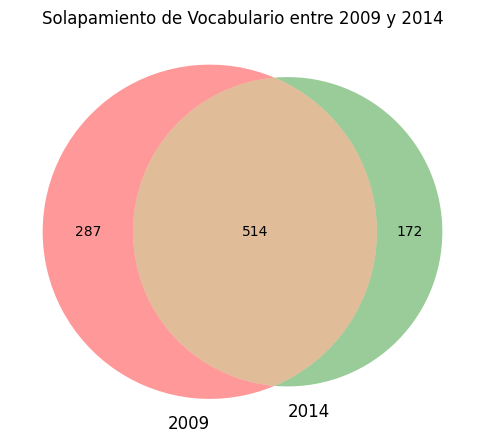

['adquisicion', 'periodo', 'joven', 'dificil', 'invitar', 'deber', 'creado', 'importancia', 'precoz']

Palabras en común entre 2014 y 2019: 393
% 28.478


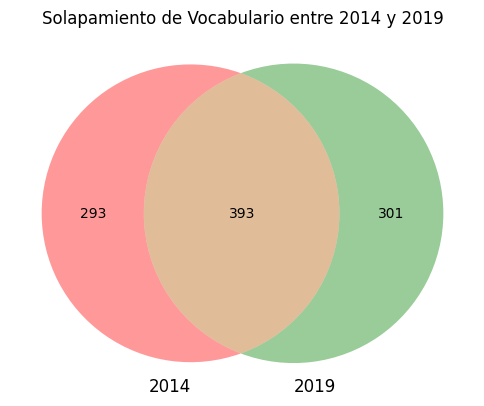

['prueba', 'raza', 'adquisicion', 'cardiomiopatia', 'disciplina', 'periodo', 'joven', 'invitar', 'ejercicio']


In [42]:
print("\n--- Palabras en Común entre Pares de Periodos ---")
for par in pares_periodos:
    periodo1 = par[0]
    periodo2 = par[1]
    vocabulario1 = set(freqs_df[freqs_df['Período'] == periodo1]['Palabra'])
    vocabulario2 = set(freqs_df[freqs_df['Período'] == periodo2]['Palabra'])
    palabras_en_comun = vocabulario1.intersection(vocabulario2)
    total = len(vocabulario1) + len(vocabulario2)
    
    num_comunes = len(palabras_en_comun)
    print(f"\nPalabras en común entre {periodo1} y {periodo2}: {num_comunes}")
    print("%",round((num_comunes/total)*100,3))

    # Visualización del solapamiento (opcional, para una idea general)
    from matplotlib_venn import venn2
    plt.figure(figsize=(6, 6))
    venn2([vocabulario1, vocabulario2], set_labels=(str(periodo1), str(periodo2)))
    plt.title(f'Solapamiento de Vocabulario entre {periodo1} y {periodo2}')
    plt.show()

    print(list(palabras_en_comun)[1:10])

Palabras en común: El número de palabras en común y los diagramas de Venn muestran la superposición del vocabulario entre los diferentes periodos. En primer para de periodos es un 36% y el segundo par 28% del vocabulario total de pares de periodos comparados.

Influencia en Vocabularios Pequeños:

* Menos palabras para comparar: Cuanto menor sea el solapamiento, menor será el conjunto de palabras para las cuales puedes directamente intentar detectar un cambio semántico comparando su uso o representaciones a través del tiempo.

* Mayor impacto de palabras nuevas y desaparecidas: Un porcentaje considerable del vocabulario siendo nuevo en un periodo o desapareciendo del otro puede indicar cambios temáticos o en el foco del discurso, lo cual podría estar relacionado con cambios semánticos en las palabras compartidas. Sin embargo, también dificulta el análisis directo del cambio semántico para las palabras no compartidas.

* Potencial para inestabilidad en modelos: Si intentas entrenar modelos de embedding o de lenguaje en vocabularios pequeños con bajo solapamiento, la falta de datos compartidos puede llevar a representaciones inestables o poco confiables para las palabras.
En resumen, un solapamiento del 29% en un vocabulario pequeño sugiere que hay una discontinuidad considerable en el léxico utilizado entre los periodos comparados, lo que puede dificultar la detección robusta de cambios semánticos utilizando métodos que se basan en la comparación directa de representaciones de palabras compartidas.

##### Palabras emergentes

* Objetivo: detectar palabras que aparecen o aumentan significativamente su uso en un período respecto a otro.

Técnicas comunes:

* Comparación de frecuencias relativas entre períodos : z-score, log-odds ratio con prior.

* TF-IDF por período: resalta palabras distintivas en un segmento temporal.

In [43]:
Vocab_periodo_df =  pd.pivot_table(freqs_df, values=['Frecuencia'], columns=['Período'],
                      index=['Palabra']).reset_index()

Vocab_periodo_df.columns = [col[1] if col[1] else col[0] for col in Vocab_periodo_df.columns]
Vocab_periodo_df.fillna(0, inplace=True) # Rellenar valores faltantes con 0
Vocab_periodo_df

,Palabra,2009,2014,2019
0,aberrante,1.0,1.0,0.0
1,abilidad,0.0,0.0,1.0
2,absoluto,1.0,1.0,0.0
3,acabar,1.0,0.0,0.0
4,acce,0.0,0.0,1.0
...,...,...,...,...
1215,volcar,0.0,0.0,1.0
1216,washington,1.0,0.0,0.0
1217,world,1.0,1.0,0.0
1218,wpw,1.0,1.0,0.0


**Calcular diferencias y Z-Score para identificar emergentes**

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

def calcular_diferencia_zscore(df, periodo1, periodo2, min_frecuencia=5):
    """
    Calcula la diferencia de frecuencia normalizada (Z-Score de la diferencia)
    para identificar palabras emergentes entre dos periodos.

    Args:
        df (pd.DataFrame): DataFrame con columnas 'palabra', 'frecuencia', 'porcentaje', 'periodo'.
        periodo1 (int): Primer periodo para la comparación.
        periodo2 (int): Segundo periodo para la comparación.
        min_frecuencia (int): Frecuencia mínima en al menos uno de los periodos para considerar la palabra.

    Returns:
        pd.DataFrame: DataFrame con palabras compartidas, sus frecuencias en ambos periodos,
                      diferencia de frecuencia y Z-Score de la diferencia.
    """
    df1 = df[df['Período'] == periodo1].set_index('Palabra')[['Frecuencia', 'Porcentaje']].add_suffix(f'_{periodo1}')
    df2 = df[df['Período'] == periodo2].set_index('Palabra')[['Frecuencia', 'Porcentaje']].add_suffix(f'_{periodo2}')

    df_comparacion = pd.concat([df1, df2], axis=1, join='outer').fillna(0)

    # Filtrar palabras con baja frecuencia en ambos periodos
    df_comparacion = df_comparacion[
        (df_comparacion[f'Frecuencia_{periodo1}'] >= min_frecuencia) |
        (df_comparacion[f'Frecuencia_{periodo2}'] >= min_frecuencia)
    ]

    df_comparacion['Diferencia_frecuencia'] = df_comparacion[f'Frecuencia_{periodo2}'] - df_comparacion[f'Frecuencia_{periodo1}']
    df_comparacion['zscore_diferencia'] = zscore(df_comparacion['Diferencia_frecuencia'])

    return df_comparacion.sort_values(by='zscore_diferencia', ascending=False)

def visualizar_palabras_emergentes(df_resultados, top_n=20, title="Palabras Emergentes (Z-Score Diferencia)"):
    """
    Visualiza las N palabras con el Z-Score de diferencia más alto.

    Args:
        df_resultados (pd.DataFrame): DataFrame con la columna 'zscore_diferencia'.
        top_n (int): Número de palabras a mostrar.
        title (str): texto_proyecto del gráfico.
    """
    top_emergentes = df_resultados.head(top_n).sort_values(by='zscore_diferencia', ascending=True)
    plt.figure(figsize=(10, 6))
    sns.barplot(x='zscore_diferencia', y=top_emergentes.index, data=top_emergentes, palette='viridis')
    plt.title(title)
    plt.xlabel("Z-Score de la Diferencia de Frecuencia")
    plt.ylabel("Palabra")
    plt.tight_layout()
    plt.show()



--- Comparación entre 2009 y 2014 ---
Cantidad de palabras emergentes, Z > 1.5 : 7


,Frecuencia_2009,Porcentaje_2009,Frecuencia_2014,Porcentaje_2014,Diferencia_frecuencia,zscore_diferencia
Palabra,,,,,,
nino,0.0,0.000000,18.0,0.009730,18.0,2.554309
deportivo,3.0,0.001749,19.0,0.010270,16.0,2.251234
programa,6.0,0.003499,22.0,0.011892,16.0,2.251234
actividad,3.0,0.001749,18.0,0.009730,15.0,2.099696
adolescente,0.0,0.000000,14.0,0.007568,14.0,1.948158
joven,1.0,0.000583,15.0,0.008108,14.0,1.948158
fisico,1.0,0.000583,15.0,0.008108,14.0,1.948158


C:\Users\Usuario\AppData\Local\Temp\ipykernel_22352\3861320564.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='zscore_diferencia', y=top_emergentes.index, data=top_emergentes, palette='viridis')


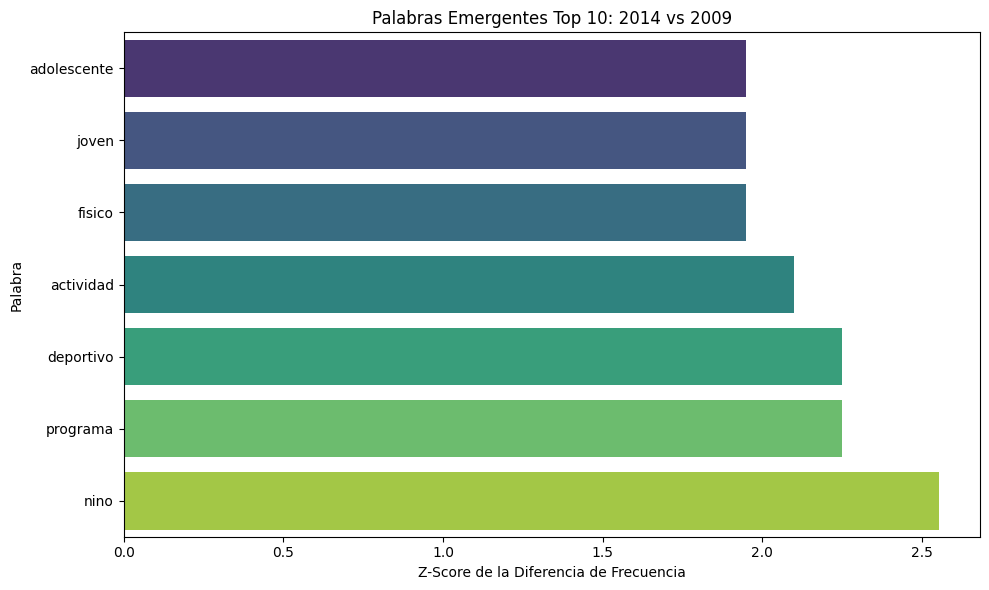


--- Comparación entre 2014 y 2019 ---
Cantidad de palabras emergentes, Z > 1.5 : 6


,Frecuencia_2014,Porcentaje_2014,Frecuencia_2019,Porcentaje_2019,Diferencia_frecuencia,zscore_diferencia
Palabra,,,,,,
establecimiento,3.0,0.001622,16.0,0.008452,13.0,3.166720
privado,1.0,0.000541,11.0,0.005811,10.0,2.416871
benicio,0.0,0.000000,8.0,0.004226,8.0,1.916971
espacio,2.0,0.001081,9.0,0.004754,7.0,1.667021
actividad,18.0,0.009730,25.0,0.013207,7.0,1.667021
destinado,4.0,0.002162,11.0,0.005811,7.0,1.667021


C:\Users\Usuario\AppData\Local\Temp\ipykernel_22352\3861320564.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='zscore_diferencia', y=top_emergentes.index, data=top_emergentes, palette='viridis')


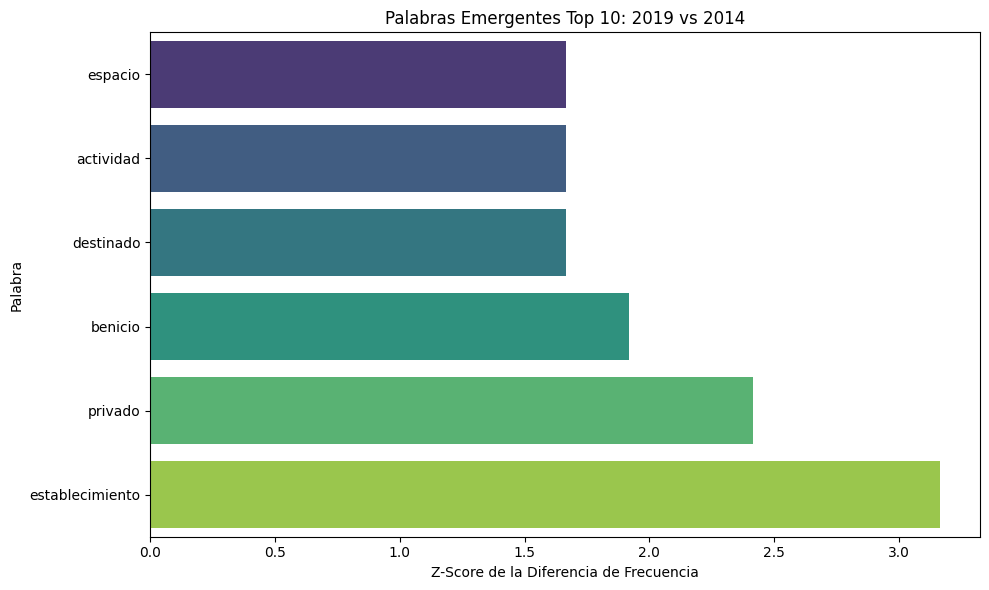


--- Comparación entre 2009 y 2019 ---
Cantidad de palabras emergentes, Z > 1.5 : 6


,Frecuencia_2009,Porcentaje_2009,Frecuencia_2019,Porcentaje_2019,Diferencia_frecuencia,zscore_diferencia
Palabra,,,,,,
nino,0.0,0.000000,23.0,0.012150,23.0,3.022812
actividad,3.0,0.001749,25.0,0.013207,22.0,2.884292
deportivo,3.0,0.001749,25.0,0.013207,22.0,2.884292
fisico,1.0,0.000583,19.0,0.010037,18.0,2.330213
establecimiento,1.0,0.000583,16.0,0.008452,15.0,1.914653
joven,1.0,0.000583,14.0,0.007396,13.0,1.637613


C:\Users\Usuario\AppData\Local\Temp\ipykernel_22352\3861320564.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='zscore_diferencia', y=top_emergentes.index, data=top_emergentes, palette='viridis')


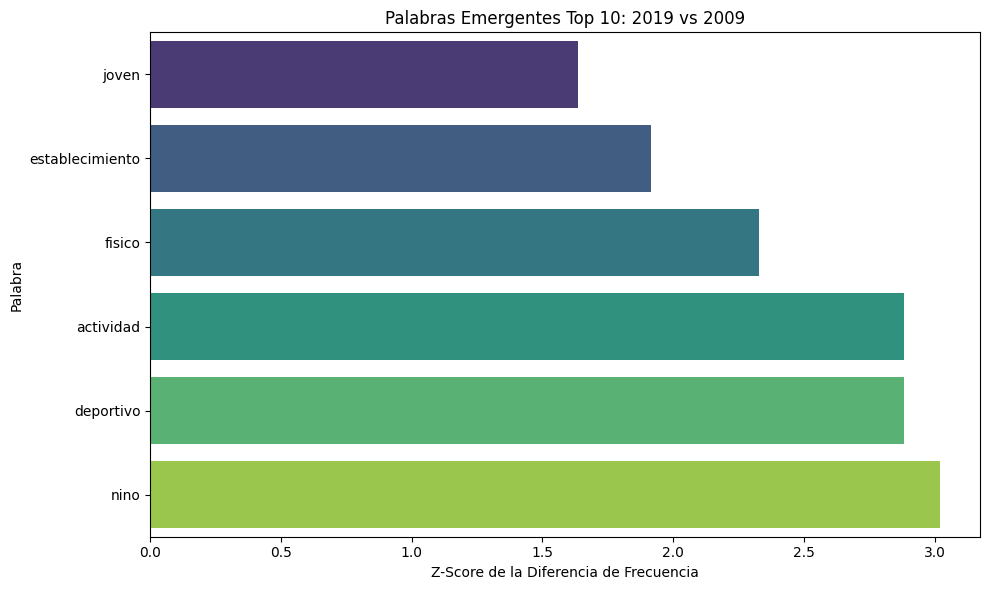

In [45]:
periodo_pares = [('2009', '2014'), ('2014', '2019'), ('2009', '2019')]

for p1, p2 in periodo_pares:
    print(f"\n--- Comparación entre {p1} y {p2} ---")
    resultados = calcular_diferencia_zscore(freqs_df.copy(), p1, p2, min_frecuencia=5)
    resultados.to_csv(RESULTADOS_DIR+'/archivos_out/zscore_'+p1+'_'+p2+'.csv')
    emergentes = resultados[resultados['zscore_diferencia']>1.5]
    print("Cantidad de palabras emergentes, Z > 1.5 :",len(emergentes))
    display(emergentes.head(10))  # Mostrar las 10 palabras más emergentes
    visualizar_palabras_emergentes(emergentes,10, title=f"Palabras Emergentes Top 10: {p2} vs {p1}")


El Z-Score estandariza la diferencia, permitiendo comparar la magnitud del cambio relativa a la variabilidad de todas las diferencias. Un Z-Score positivo alto sugiere una mayor emergencia en el segundo periodo. Se consideraron emergentes aquellas palabras con un z-score superior a 1.5, es decir, cuyo crecimiento superó en al menos 1.5 desviaciones estándar el crecimiento promedio del conjunto. Este umbral permite detectar términos que se destacan significativamente sin restringir el análisis a casos extremos.

* Se observa la palabra 'actividad' con  Z-Scores extremos, tal que están presentes en los tres períodos. La palabra nino y deportivo son importantes en la detección de cambios.

Ruido: Las palabras que aparecen con muy poca frecuencia pueden tener grandes cambios relativos en su porcentaje o frecuencia debido a una sola aparición o desaparición. Estos cambios pueden generar Z-Scores altos pero no ser semánticamente significativos o robustos. El umbral min_frecuencia intenta mitigar esto, pero elegir el umbral adecuado puede ser difícil.

Estimaciones inestables: Las estadísticas basadas en conteos bajos pueden ser inestables y sensibles a pequeñas fluctuaciones en los datos.
Problemas con poco vocabulario compartido:

Análisis limitado: El enfoque solo puede analizar las palabras que están presentes en ambos periodos comparados. Ignora las palabras que emergen completamente en un periodo o desaparecen del otro, las cuales podrían ser indicadores importantes de cambio semántico o temático.

Sesgo en la comparación: Si el vocabulario compartido es pequeño y no representativo de los cambios lingüísticos generales, las conclusiones basadas en él podrían estar sesgadas.

##### log-odds ratio (con o sin prior bayesiano) 
https://www.cambridge.org/core/journals/political-analysis/article/fightin-words-lexical-feature-selection-and-evaluation-for-identifying-the-content-of-political-conflict/81B3703230D21620B81EB6E2266C7A66


El log-odds ratio compara la probabilidad de que una palabra aparezca en un corpus A (ej. 2019–2023) frente a un corpus B (ej. 2009–2013). Cuanto más alta (positiva) sea la puntuación, más característica o "emergente" es la palabra en A. Si es muy negativa, es distintiva de B.
Fue propuesto y difundido por Monroe et al. (2008) en análisis político y por Eisenstein et al. (2014) para redes sociales.

Corrige el ruido de palabras que aparecen muy poco. Es más confiable que mirar frecuencias absolutas o proporc crudas. Permite comparar muchos términos de forma estadísticamente sólida incluso en corpus pequeños. 

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calcular_log_odds_ratio_apriori(frecuencia_periodo1, total_tokens_periodo1,
                                    frecuencia_periodo2, total_tokens_periodo2,
                                    prior_apriori=0.5):
    """
    Calcula el log-odds ratio con un prior a priori (Bayesiano).
    (Misma función que antes)
    """
    n11 = frecuencia_periodo2
    n10 = total_tokens_periodo2 - frecuencia_periodo2
    n01 = frecuencia_periodo1
    n00 = total_tokens_periodo1 - frecuencia_periodo1

    odds_ratio = ((n11 + prior_apriori) * (n00 + prior_apriori)) / ((n10 + prior_apriori) * (n01 + prior_apriori))

    if odds_ratio == 0:
        return -np.inf
    elif np.isinf(odds_ratio):
        return np.inf
    else:
        return np.log(odds_ratio)

In [47]:
def identificar_palabras_emergentes_lor(df, periodo1, periodo2, prior=0.5, umbral_lor=1.0):
    """
    Identifica palabras emergentes entre dos periodos usando el log-odds ratio Bayesiano.

    Args:
        df (pd.DataFrame): DataFrame con columnas 'palabra', 'frecuencia', 'periodo'.
        periodo1 (int): Primer periodo para la comparación.
        periodo2 (int): Segundo periodo para la comparación (donde buscamos emergencia).
        prior (float): Valor del prior a priori.
        umbral_lor (float): Umbral para considerar una palabra como emergente (LOR positivo y mayor que el umbral).

    Returns:
        pd.DataFrame: DataFrame con las palabras compartidas entre los periodos, sus frecuencias,
                      el log-odds ratio y una columna booleana indicando si la palabra es emergente.
    """
    df1 = df[df['Período'] == periodo1].set_index('Palabra')['Frecuencia'].rename(f'Frecuencia_{periodo1}')
    df2 = df[df['Período'] == periodo2].set_index('Palabra')['Frecuencia'].rename(f'Frecuencia_{periodo2}')

    df_comparacion = pd.concat([df1, df2], axis=1, join='outer').fillna(0)


    total_tokens_p1 = df[df['Período'] == periodo1]['Frecuencia'].sum()
    total_tokens_p2 = df[df['Período'] == periodo2]['Frecuencia'].sum()

    df_comparacion['log_odds_ratio'] = df_comparacion.apply(
        lambda row: calcular_log_odds_ratio_apriori(
            row[f'Frecuencia_{periodo1}'], total_tokens_p1,
            row[f'Frecuencia_{periodo2}'], total_tokens_p2,
            prior
        ),
        axis=1
    )

    df_comparacion['es_emergente'] = (df_comparacion['log_odds_ratio'] > umbral_lor)

    return df_comparacion.sort_values(by='log_odds_ratio', ascending=False)

def visualizar_palabras_emergentes_lor(df_resultados, top_n=20, title="Palabras Emergentes (Log-Odds Ratio)"):
    """
    Visualiza las N palabras con el log-odds ratio más alto.

    Args:
        df_resultados (pd.DataFrame): DataFrame con la columna 'log_odds_ratio'.
        top_n (int): Número de palabras a mostrar.
        title (str): texto_proyecto del gráfico.
    """
    top_emergentes = df_resultados.head(top_n).sort_values(by='log_odds_ratio', ascending=True)
    plt.figure(figsize=(10, 6))
    sns.barplot(x='log_odds_ratio', y=top_emergentes.index, data=top_emergentes, palette='viridis')
    plt.title(title)
    plt.xlabel("Log-Odds Ratio (Bayesiano)")
    plt.ylabel("Palabra")
    plt.tight_layout()
    plt.show()

In [48]:
def visualizar_top_odds_ratios(df, columna_lor, n=20, title="Top Palabras por Log-Odds Ratio"):
    """
    Visualiza las N palabras con los log-odds ratios más altos y más bajos.

    Args:
        df (pd.DataFrame): DataFrame con los resultados del análisis LOR.
        columna_lor (str): Nombre de la columna que contiene los valores de LOR.
        n (int): Número de palabras a mostrar en cada extremo.
        title (str): texto_proyecto del gráfico.
    """
    top_n = df.sort_values(by=columna_lor, ascending=False).head(n)
    bottom_n = df.sort_values(by=columna_lor, ascending=True).head(n)
    combined = pd.concat([top_n, bottom_n]).sort_values(by=columna_lor, ascending=False)

    plt.figure(figsize=(10, 12))
    sns.barplot(x=columna_lor, y=combined.index, data=combined, palette="coolwarm")
    plt.title(title)
    plt.xlabel("Log-Odds Ratio")
    plt.ylabel("Palabra")
    plt.tight_layout()
    plt.show()



--- Comparación entre 2009 y 2014 ---
Cantidad de palabras emergentes : 190

--- Palabras emergentes en 2014 comparado con 2009 ---


,Frecuencia_2009,Frecuencia_2014,log_odds_ratio,es_emergente
Palabra,,,,
nino,0.0,18.0,3.544941,True
adolescente,0.0,14.0,3.299139,True
examen,0.0,10.0,2.974190,True
ecg,0.0,10.0,2.974190,True
deporte,0.0,10.0,2.974190,True
deportista,0.0,10.0,2.974190,True
screening,0.0,8.0,2.761795,True
evaluacion,0.0,8.0,2.761795,True
chequeo,0.0,8.0,2.761795,True


C:\Users\Usuario\AppData\Local\Temp\ipykernel_22352\1245074900.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='log_odds_ratio', y=top_emergentes.index, data=top_emergentes, palette='viridis')


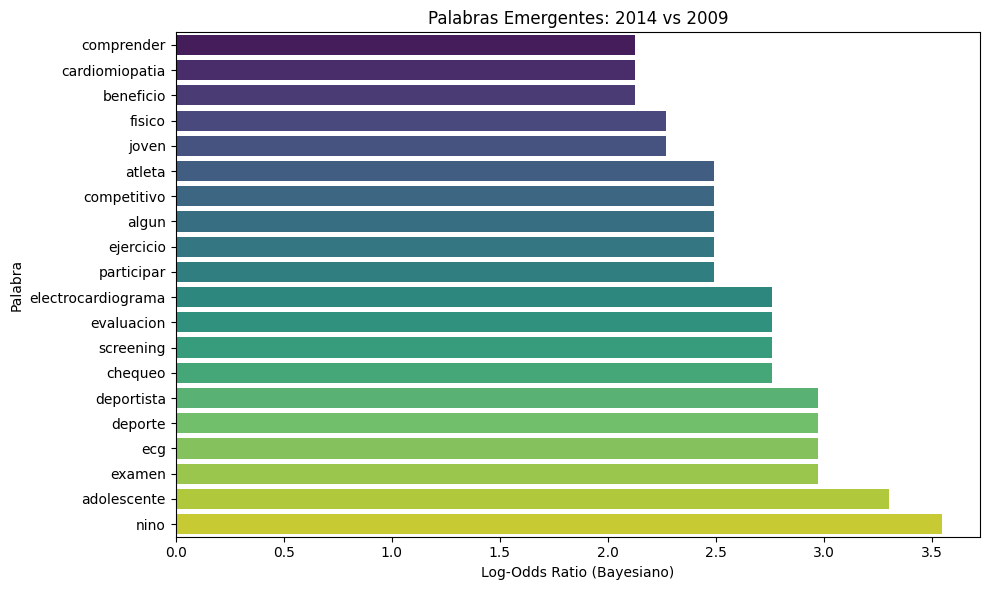

C:\Users\Usuario\AppData\Local\Temp\ipykernel_22352\3997417559.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=columna_lor, y=combined.index, data=combined, palette="coolwarm")


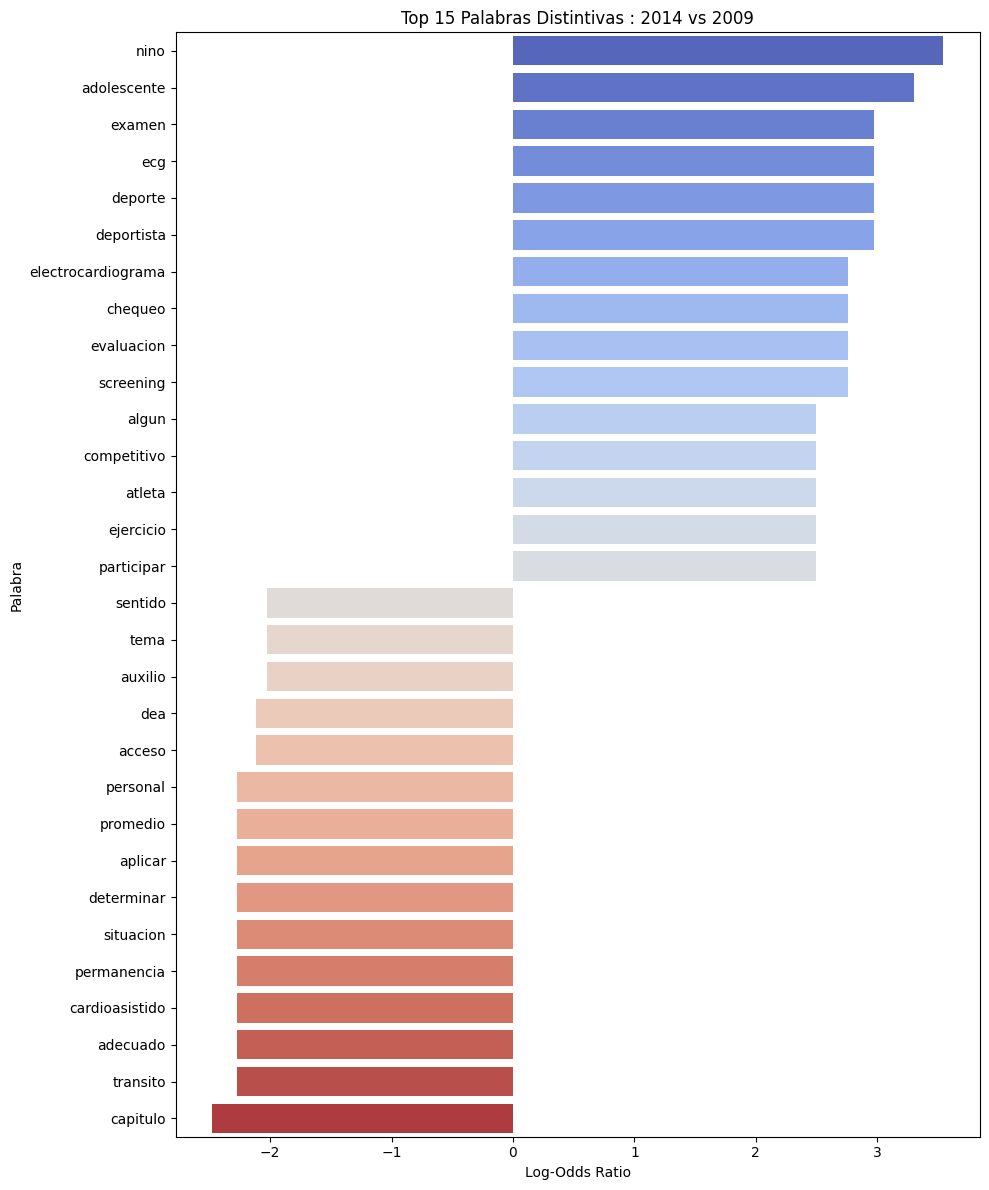


--- Comparación entre 2014 y 2019 ---
Cantidad de palabras emergentes : 313

--- Palabras emergentes en 2019 comparado con 2014 ---


,Frecuencia_2014,Frecuencia_2019,log_odds_ratio,es_emergente
Palabra,,,,
benicio,0.0,8.0,2.814476,True
resultar,0.0,6.0,2.545152,True
asistencia,0.0,5.0,2.377568,True
alojamiento,0.0,5.0,2.377568,True
inversion,0.0,5.0,2.377568,True
pileta,0.0,5.0,2.377568,True
frente,0.0,5.0,2.377568,True
sector,0.0,5.0,2.377568,True
situacion,0.0,4.0,2.176368,True


C:\Users\Usuario\AppData\Local\Temp\ipykernel_22352\1245074900.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='log_odds_ratio', y=top_emergentes.index, data=top_emergentes, palette='viridis')


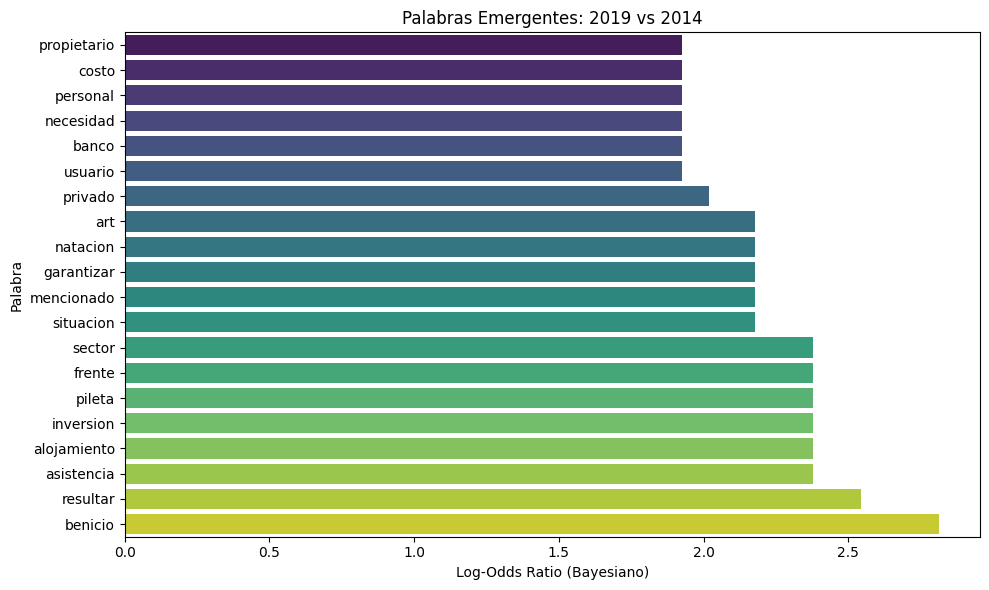

C:\Users\Usuario\AppData\Local\Temp\ipykernel_22352\3997417559.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=columna_lor, y=combined.index, data=combined, palette="coolwarm")


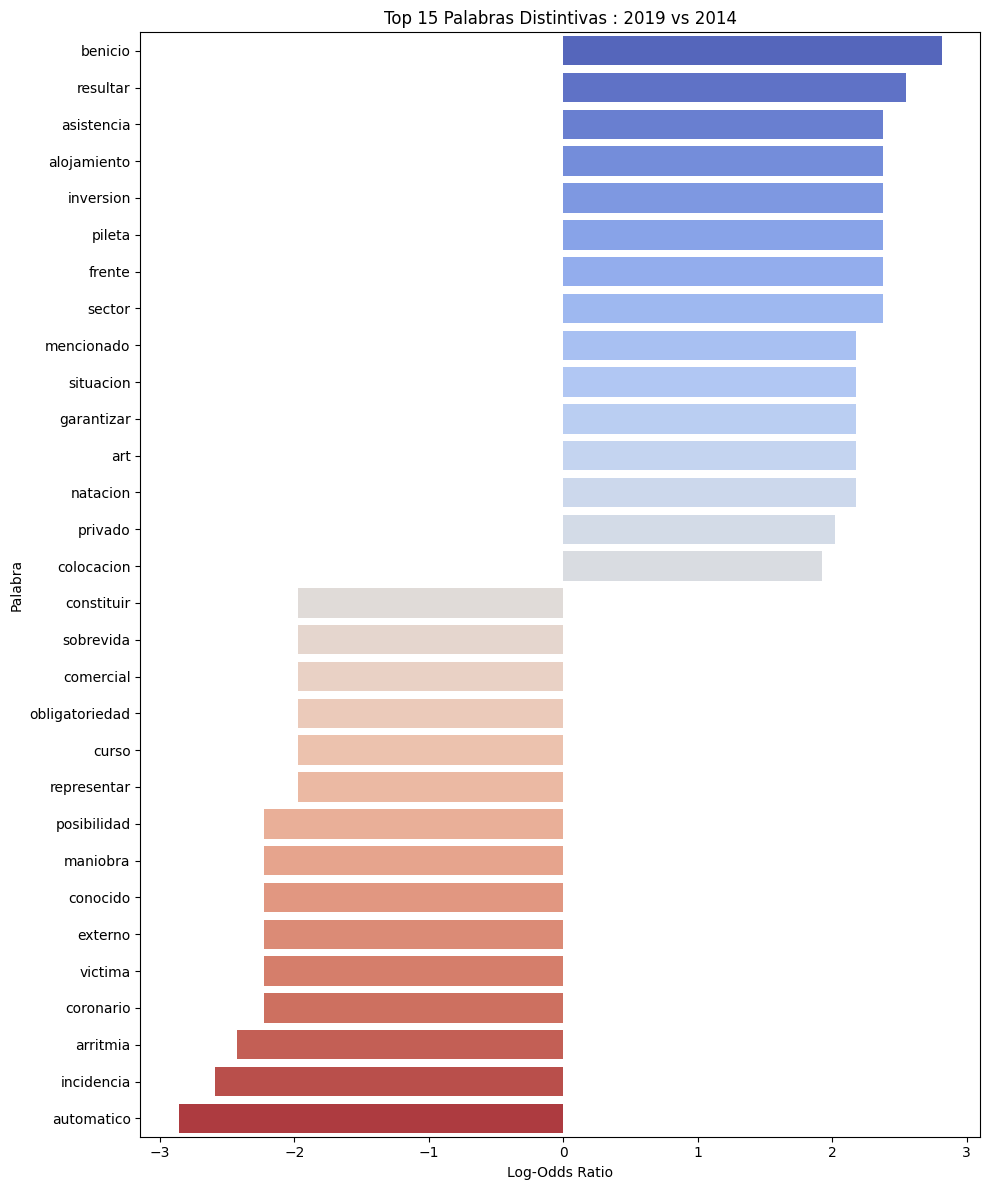


--- Comparación entre 2009 y 2019 ---
Cantidad de palabras emergentes : 438

--- Palabras emergentes en 2019 comparado con 2009 ---


,Frecuencia_2009,Frecuencia_2019,log_odds_ratio,es_emergente
Palabra,,,,
nino,0.0,23.0,3.763646,True
adolescente,0.0,12.0,3.126511,True
deporte,0.0,12.0,3.126511,True
examen,0.0,10.0,2.951095,True
deportista,0.0,10.0,2.951095,True
ecg,0.0,10.0,2.951095,True
electrocardiograma,0.0,8.0,2.738725,True
evaluacion,0.0,8.0,2.738725,True
screening,0.0,8.0,2.738725,True


C:\Users\Usuario\AppData\Local\Temp\ipykernel_22352\1245074900.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='log_odds_ratio', y=top_emergentes.index, data=top_emergentes, palette='viridis')


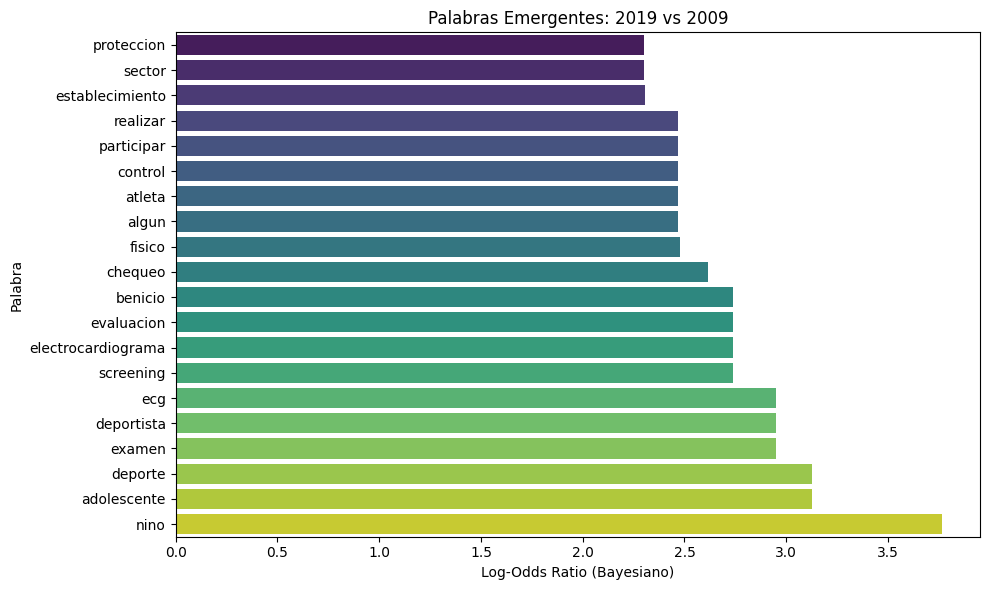

C:\Users\Usuario\AppData\Local\Temp\ipykernel_22352\3997417559.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=columna_lor, y=combined.index, data=combined, palette="coolwarm")


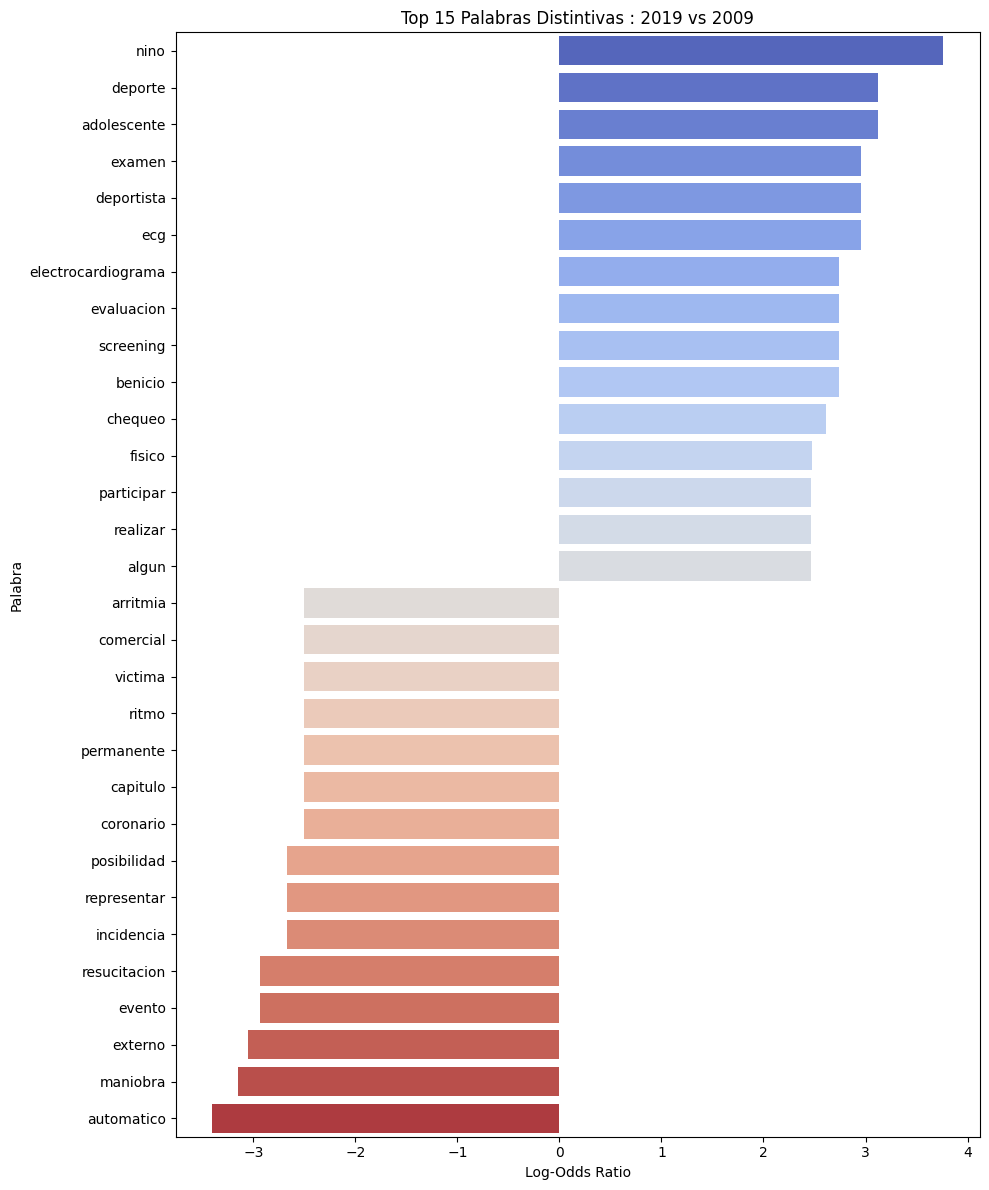

In [49]:
periodo_pares = [('2009', '2014'), ('2014', '2019'), ('2009', '2019')]

for p1, p2 in periodo_pares:
    print(f"\n--- Comparación entre {p1} y {p2} ---")
    periodo_emergente = p2
    periodo_referencia = p1

    resultados_emergentes = identificar_palabras_emergentes_lor(
        freqs_df.copy(), periodo_referencia, periodo_emergente, prior=0.5, umbral_lor=1
    )

    resultados_emergentes.to_csv(RESULTADOS_DIR+'/archivos_out/lor_'+p1+'_'+p2+'.csv')
    print("Cantidad de palabras emergentes :",len(resultados_emergentes[resultados_emergentes['es_emergente']==True]))

    print(f"\n--- Palabras emergentes en {periodo_emergente} comparado con {periodo_referencia} ---")
    display(resultados_emergentes.head(10))
    visualizar_palabras_emergentes_lor(resultados_emergentes, title=f"Palabras Emergentes: {periodo_emergente} vs {periodo_referencia}")
    visualizar_top_odds_ratios(resultados_emergentes, 'log_odds_ratio', n=15, title=f"Top 15 Palabras Distintivas : {periodo_emergente} vs {periodo_referencia}")


LOR > 0: Indica que la palabra tiene una mayor probabilidad de aparecer en el grupo 1 (generalmente el periodo de tiempo más reciente o el corpus de interés) en comparación con el grupo 2 (el periodo de referencia). Cuanto mayor sea el valor positivo, más fuerte es la evidencia de que la palabra está emergiendo o aumentando su uso en el grupo 1.

LOR < 0: Indica que la palabra tiene una menor probabilidad de aparecer en el grupo 1 en comparación con el grupo 2. Un valor negativo grande sugiere que la palabra está disminuyendo su uso o era más común en el grupo de referencia.


LOR ≈ 0: Indica que la probabilidad de la palabra es similar en ambos grupos. Estas palabras probablemente no son emergentes ni en declive significativo.

Se consider un prior pequeño y constante como 0.5. Esta es una práctica común. Habría que analizar otros.

Comparación entre 2009 y 2014:

* Cantidad de palabras emergentes: 190. Esto significa que se identificaron 190 palabras que aumentaron significativamente en su frecuencia de uso en los textos sobre muerte súbita en 2014 en comparación con 2009.
* Palabras emergentes clave: Las 10 palabras principales que emergieron con los LOR más altos son:
* nino (LOR: 3.54): La palabra "niño" se volvió mucho más frecuente en los textos sobre muerte súbita en 2014 que en 2009. Esto podría indicar un mayor enfoque en la población infantil en relación con esta condición.
* adolescente (LOR: 3.29): Similar a "niño", la palabra "adolescente" también experimentó un aumento significativo, sugiriendo una mayor atención a este grupo de edad.
* examen (LOR: 2.97), ecg (LOR: 2.97), deporte (LOR: 2.97), deportista (LOR: 2.97): La emergencia de estas palabras sugiere que en 2014 hubo una mayor discusión sobre la importancia de los exámenes (específicamente el electrocardiograma - ECG), la relación entre el deporte y la muerte súbita, y la población de deportistas.
*screening (LOR: 2.76), evaluacion (LOR: 2.76), chequeo (LOR: 2.76), electrocardiograma (LOR: 2.76): Estas palabras refuerzan la idea de un mayor énfasis en la detección temprana a través de "screening" o "chequeos" y la "evaluación" cardiológica, con mención explícita del "electrocardiograma" como herramienta clave.

Comparación entre 2014 y 2019:

* Cantidad de palabras emergentes: 313. Un número aún mayor de palabras se volvieron significativamente más frecuentes en 2019 en comparación con 2014.
* Palabras emergentes clave: Las 10 palabras principales que emergieron tienen un carácter diferente a las del periodo anterior:
* benicio (LOR: 2.81): Esta palabra probablemente se refiere a un nombre propio (posiblemente de un investigador, una figura pública o un caso específico relevante en ese periodo). Su emergencia sugiere que esta persona o caso ganó prominencia en la discusión sobre la muerte súbita.


Comparación entre 2009 y 2019:

* Cantidad de palabras emergentes: 438. Al comparar el periodo inicial con el final, se observa la mayor cantidad de palabras que se volvieron significativamente más frecuentes.
* Palabras emergentes clave: Las 10 palabras principales que emergieron al comparar 2019 con 2009 combinan elementos de las comparaciones anteriores:
nino (LOR: 3.76), adolescente (LOR: 3.12), deporte (LOR: 3.12), examen (LOR: 2.95), deportista (LOR: 2.95), ecg (LOR: 2.95), electrocardiograma (LOR: 2.73), evaluacion (LOR: 2.73), screening (LOR: 2.73), benicio (LOR: 2.73): Esta lista sugiere una tendencia consistente a lo largo de la década. El enfoque en la población joven, la evaluación cardiológica (con énfasis en el ECG) en el contexto deportivo y la aparición de "benicio" como un elemento nuevo y significativo en 2019.





el análisis LOR sugiere una evolución en el lenguaje utilizado en relación con la muerte súbita, con un aumento significativo en la frecuencia de términos relacionados con la población joven, la evaluación cardiológica y la detección a lo largo del tiempo. La aparición de nombres propios como "benicio" puede señalar la influencia de eventos o figuras específicas en la discusión en periodos posteriores.

##### TF-IDF por período 

In [50]:
docs_por_periodo = pd.Series(PER5anios_df['texto_proyecto normalizado'].values, index =PER5anios_df['Periodo_5anios'])
docs_por_periodo

Periodo_5anios
2009                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [51]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer


# Aplicamos TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(docs_por_periodo)

# Creamos un DataFrame con los resultados
tfidf_df = pd.DataFrame(tfidf_matrix.T.toarray(), 
                        index=vectorizer.get_feature_names_out(), 
                        columns=docs_por_periodo.index)

# Mostrar las top palabras distintivas por período
for periodo in tfidf_df.columns:
    print(f"\n Palabras más distintivas en {periodo}")
    display(tfidf_df[periodo].sort_values(ascending=False).head(10))


 Palabras más distintivas en 2009


persona       0.240963
dea           0.240963
articulo      0.240963
lugar         0.213159
publico       0.203892
cardiaco      0.185356
ley           0.157553
automatico    0.155142
deber         0.139017
proyecto      0.139017
Name: 2009, dtype: float64


 Palabras más distintivas en 2014


articulo       0.239099
nino           0.205256
programa       0.194822
deportivo      0.168255
cardiaco       0.168255
adolescente    0.159643
actividad      0.159399
causa          0.141688
fisico         0.132833
joven          0.132833
Name: 2014, dtype: float64


 Palabras más distintivas en 2019


nino               0.246381
deportivo          0.207975
actividad          0.207975
articulo           0.199656
fisico             0.158061
deber              0.133104
programa           0.133104
establecimiento    0.133104
deporte            0.128547
adolescente        0.128547
Name: 2019, dtype: float64

Se aplicó la métrica TF-IDF sobre los textos agrupados por períodos de 5 años, considerando cada período como un “documento agregado”. Esta estrategia permitió identificar términos con alta relevancia local, palabras distintivas que caracterizan el discurso legislativo sobre salud en cada período analizado.

In [55]:

def mostrar_ejemplos_contextuales(df, palabra, periodo, n=5):
    """
    Muestra ejemplos de texto_proyectos que contienen una palabra específica en un periodo.

    Args:
        df (pd.DataFrame): DataFrame con columnas 'titulo' (o la columna de texto_proyectos) y 'periodo'.
        palabra (str): La palabra para buscar en los texto_proyectos (insensible a mayúsculas/minúsculas).
        periodo (int): El periodo de interés.
        n (int): Número de ejemplos a mostrar.
    """
    df_periodo = df[df['Periodo_5anios'] == periodo]
    texto_con_palabra = df_periodo[df_periodo['texto_proyecto normalizado'].str.lower().str.contains(palabra.lower(), na=False)]

    if not titulos_con_palabra.empty:
        print(f"\nEjemplos de texto_proyectos conteniendo '{palabra}' en el periodo {periodo}:")
        display(texto_con_palabra[['texto_proyecto','texto_proyecto normalizado']].head(n))
    
    else:
        print(f"No se encontraron texto_proyectos conteniendo '{palabra}' en el periodo {periodo}.")


### Para Análisis Cualitativo y Lingüístico 

In [56]:
basetexto_df.columns

Index(['Proyecto.ID', 'texto_proyecto', 'texto_proyecto procesado',
       'texto_proyecto normalizado', 'Cant_token', 'Cant_token_normalizado',
       'Proyecto_girado_a_comisiones_SALUD', 'Proyecto_SALUD', 'Resultado',
       'Max_Orden', 'Tiene_antecedente_por_titulo_proy', 'Periodo', 'Año',
       'Tokens', 'Periodo_5anios'],
      dtype='object')

In [57]:
# Ejemplo de cómo usar la función para ver el contexto
palabra_ejemplo = 'nacional'
for periodo in [2009,2014,2019]:
    mostrar_ejemplos_contextuales_titulos(basetexto_df.copy(), palabra_ejemplo, periodo, n=3)




Ejemplos de texto_proyectos conteniendo 'nacional' en el periodo 2009:


texto_proyecto  \
7  3926-D-2012\nProyecto\nEl Senado y Cámara de Diputados...\nLEY DE PREVENCIÓN DE LA MUERTE \nSÚBITA EN ESPACIOS DE ACCESO PÚBLICO\nCapítulo I\nDisposiciones Generales\nArtículo 1º.- Objeto. El objeto de la \npresente ley es regular un sistema de prevención integral de eventos por muerte \nsúbita en espacios públicos y privados de acceso público.\nArtículo 2°.- Definiciones. A los \nefectos de esta ley se considera:\na) Resucitación cardiopulmonar - RCP \n-: maniobras que se llevan a cabo sobre una persona en caso de detención de su \ncirculación de la sangre y que están destinadas a la oxigenación inmediata de los \nórganos vitales.\nb) Desfibrilación: maniobras de RCP a \nlas que se incluye un desfibrilador externo automático - DEA -.\nc) Desfibrilador externo automático - \nDEA -: dispositivo portátil utilizado para estimular eléctricamente el corazón de una \npersona que está en paro cardíaco.\nd) Espacios públicos y privados de \nacceso público: lugares con tránsito o permanencia de hasta por lo menos \nquinientas (500) personas de promedio. Para el caso de las industrias, fábricas, \ncentros comerciales, hoteles o paradores o cualquier otra empresa privada, el \ntránsito o permanencia se determina en hasta por lo menos doscientos cincuenta \n(250) personas de promedio.\ne) Lugares cardioasistidos: espacios \nque disponen de los elementos necesarios para asistir a una persona en los \nprimeros minutos tras un paro cardíaco.\nf) Cadena de supervivencia: conjunto \nde acciones sucesivas y coordinadas que permiten aumentar la posibilidad de \nsobrevivir de la persona que es víctima de eventos como un paro \ncardiorrespiratorio, electrocución, asfixia, sofocación u atragantamiento.\nArtículo 3°.- La autoridad de \naplicación de la presente ley es el Ministerio de Salud, el que debe coordinar su \naplicación con las jurisdicciones en el marco del Consejo Federal de Salud -COFESA \n-.\nCapítulo II\nObjetivos\nArtículo 4°.- Objetivos. En el marco \ndel sistema establecido la autoridad de aplicación debe promover los siguientes \nobjetivos:\na)  Promoción del acceso público a la \nresucitación cardiopulmonar y a la desfibrilación.\nb) Reducción de la morbimortalidad \nsúbita de eventos de origen cardiovascular u otros como electrocución, asfixia, \nsofocación y atragantamiento.\nc) Promoción del conocimiento por \nparte de la población sobre la importancia de los lugares cardioasistidos y de la \ndisponibilidad de la cadena de supervivencia.\nd) Promoción  del acceso de la \npoblación a la información sobre primeros auxilios, maniobras de resucitación \ncardiopulmonar básica y desfibrilación automática externa.\ne) Promoción de la instrucción básica \nde primeros auxilios, maniobras de resucitación cardiopulmonar básica y \ndesfibrilación automática externa en los niveles educativo y comunitario.\nf) Determinación de las pautas de \nacreditación para la capacitación del personal de los lugares establecidos, en \ntécnicas de maniobras de resucitación cardiopulmonar básica y en el uso de los \nDEA.\ng) Desarrollo de un sistema de \ninformación y estadística de la morbimortalidad súbita y sus riesgos a nivel \nnacional.\nCapítulo III\nInstalación y utilización de los DEA\nArtículo 5°.- Instalación de DEA. Los \nespacios públicos y los privados de acceso público deben tener instalado al menos \nun DEA en condiciones de ser utilizado en forma permanente.\nArtículo 6°.- Ubicación de los DEA. \nLos DEA deben ser instalados en lugares de fácil acceso para su uso y deben estar \nclaramente indicados por carteles alusivos.\nArtículo 7°.- Mantenimiento. Los \ntitulares o los responsables de la administración o explotación de los espacios \ndeterminados en el artículo 2° deben mantener en forma permanente el DEA en \ncondiciones aptas de funcionamiento para su uso inmediato por las personas que \ntransiten o permanezcan el lugar.\nArtículo 8°.- Habilitación. Los DEA \ndeben tener la habilitación vigente otorgada por el org


Ejemplos de texto_proyectos conteniendo 'nacional' en el periodo 2014:


texto_proyecto  \
4                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             


Ejemplos de texto_proyectos conteniendo 'nacional' en el periodo 2019:


texto_proyecto  \
1                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 \nPROYECTO DE LEY  \nEl Senado y Cámara de Diputados, ...  \nCREACION DEL PROGRAMA DE DIFUSION E INFORMACION A PADRES Y \nMIEMBROS DE LA COMUNIDAD ESCOLAR DESTINADO A PREVENIR LA \nMUERTE SUBITA. REGIMEN. CAPACITACION EN REANIMACION \nCARDIOPULMONAR  \n \nARTÍCULO 1° - Crease el programa de difusión e información a padres, alumnos, \nmaestros y profesores y de capacitación en reanimación cardiovascular básica \ndestinada a cada uno de los distintos estamentos de la institución  escolar.   \n \nARTÍCULO 2° - Se establece con caráct er obligatorio un chequeo cardiológico al \ningreso de la escuela primaria y en el ingreso de la escuela secundaria.  \n \nARTÍCULO 3° - Para aquellos estudiantes que participan en programas \ndeportivos organizados deberá ser repetido cada 2 años.  \n \nARTÍCULO 4° - Dicho control debe incluir un examen físico, Electrocardiograma, \ny Ecocardiograma. Para el grupo establecido en el artículo 3º se agregará un \nECG de esfuerzo.  \n \nARTÍCULO 5º - Los establecimientos médico -asistenciales públicos, los de la \nseguri dad soc